In [1]:
import pyspark.sql.functions as f
import pyspark.sql.dataframe
import pyspark.pandas as ps
from pyspark.sql.window import Window, WindowSpec
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
# Show all columns
pd.set_option('display.max_columns', None)

In [2]:
%run importa_dados_spark.py

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/02 15:34:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
sinistros.columns

['id_sinistro',
 'tipo_registro',
 'data_sinistro',
 'ano_sinistro',
 'mes_sinistro',
 'dia_sinistro',
 'hora_sinistro',
 'ano_mes_sinistro',
 'dia_da_semana',
 'turno',
 'logradouro',
 'numero_logradouro',
 'tipo_via',
 'tipo_local',
 'latitude',
 'longitude',
 'cod_ibge',
 'municipio',
 'regiao_administrativa',
 'administracao',
 'conservacao',
 'circunscricao',
 'tp_sinistro_primario',
 'qtd_pedestre',
 'qtd_bicicleta',
 'qtd_motocicleta',
 'qtd_automovel',
 'qtd_onibus',
 'qtd_caminhao',
 'qtd_veic_outros',
 'qtd_veic_nao_disponivel',
 'qtd_gravidade_fatal',
 'qtd_gravidade_grave',
 'qtd_gravidade_leve',
 'qtd_gravidade_ileso',
 'qtd_gravidade_nao_disponivel',
 'tp_sinistro_atrop_pedestre',
 'tp_sinistro_atrop_vitima_fora_veic',
 'tp_sinistro_colisao_frontal',
 'tp_sinistro_colisao_traseira',
 'tp_sinistro_colisao_lateral',
 'tp_sinistro_colisao_transversal',
 'tp_sinistro_colisao_outros',
 'tp_sinistro_choque',
 'tp_sinistro_atrop_animal',
 'tp_sinistro_capotamento',
 'tp_sinistro

In [5]:
#Filtrando dados apenas de vias públicas
#69 registros encontrados sem o preenchimento do horário da ocorrência, estão sendo retirados da base por insignificância estatística para facilitar a análise
sinistros = sinistros \
            .filter(f.col('tipo_local') == 'PUBLICO') \
            .filter(f.col('hora_sinistro').isNotNull()) \
            .withColumn('fatalidade', f.when(f.col('tipo_registro') == 'SINISTRO FATAL', 'SIM').otherwise('NAO')) \
            .withColumn('minuto', f.right('hora_sinistro', f.lit(2)).cast('int')) \
            .withColumn('hora', f.left('hora_sinistro', f.lit(2)).cast('int'))

columns = ['hora', 'dia_da_semana', 'tipo_via', 'tp_sinistro_primario', 'circunscricao', 'turno']

In [6]:
sinistros.groupBy('tipo_via').count().toPandas()

,tipo_via,count
0,NAO DISPONIVEL,45
1,ESTRADAS E RODOVIAS,9945
2,VIAS URBANAS,67182


In [22]:
def col_order(col: str):
    COL_ORDER = {'dia_da_semana': ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo'],
             'turno': ['MADRUGADA', 'MANHA', 'TARDE', 'NOITE'],
             'fatalidade': ['NAO', 'SIM']}
    
    return COL_ORDER.get(col)

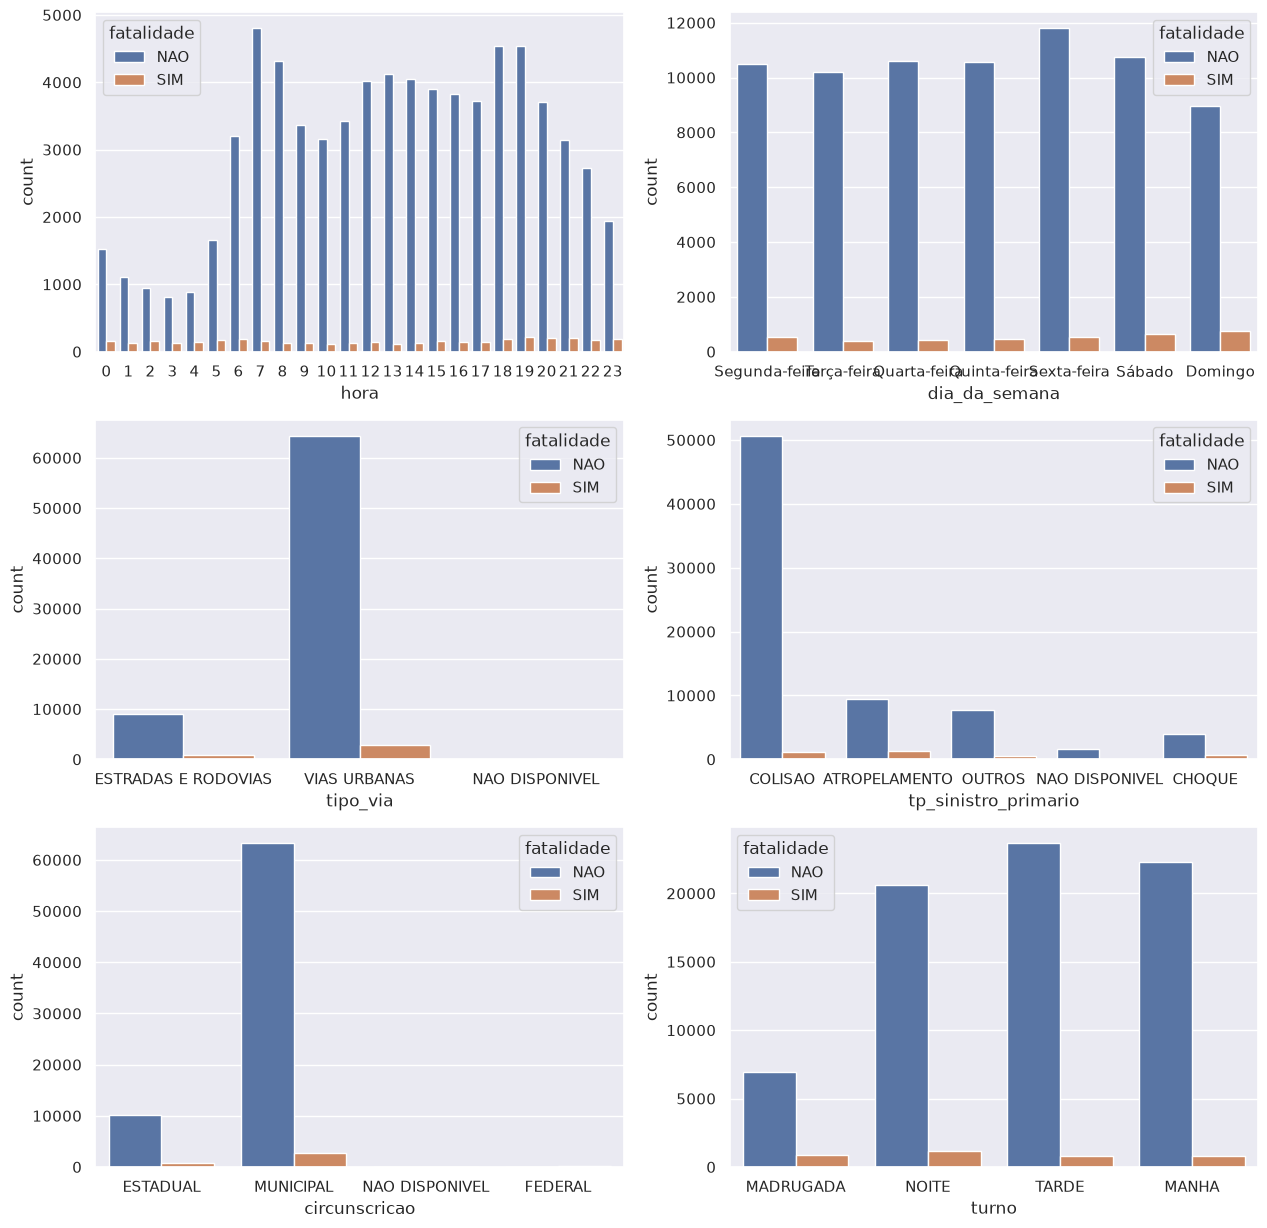

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i, column in enumerate(columns):
    sns.countplot(data=sinistros.toPandas(), x=column, hue='fatalidade', ax=axes[i], hue_order=col_order('fatalidade'))

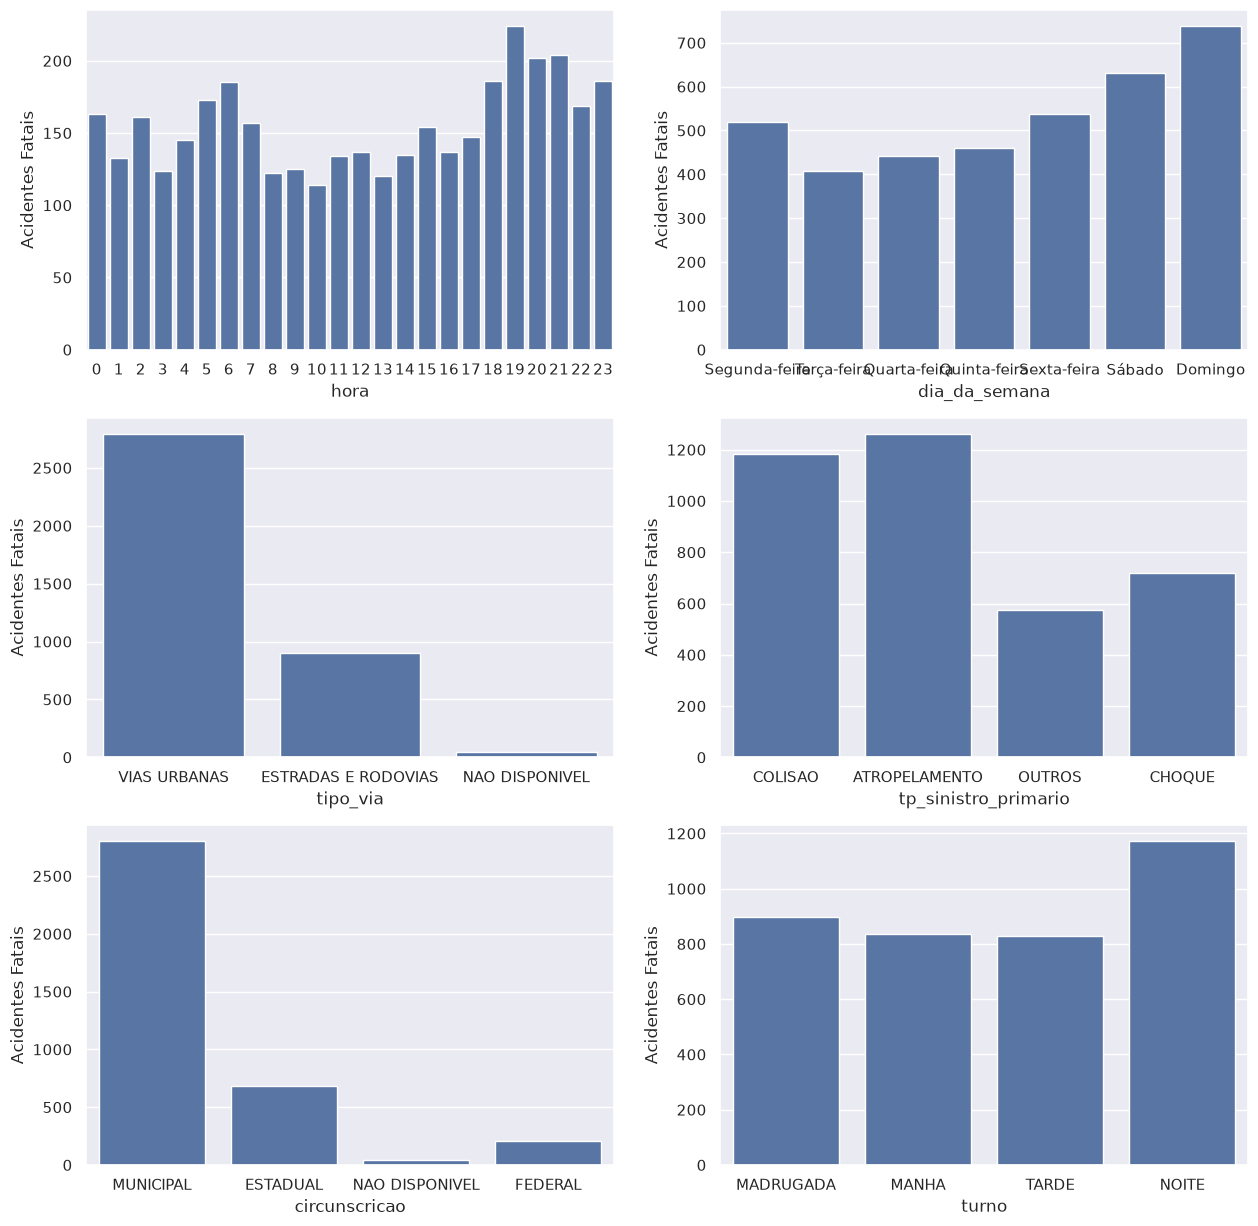

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i, column in enumerate(columns):
    sns.countplot(data=sinistros.filter(f.col('fatalidade') == 'SIM').toPandas(), x=column, ax=axes[i], order=col_order(column))
    axes[i].set_ylabel('Acidentes Fatais')

Text(0.5, 1.0, 'Número de mortes por dia da semana e hora.')

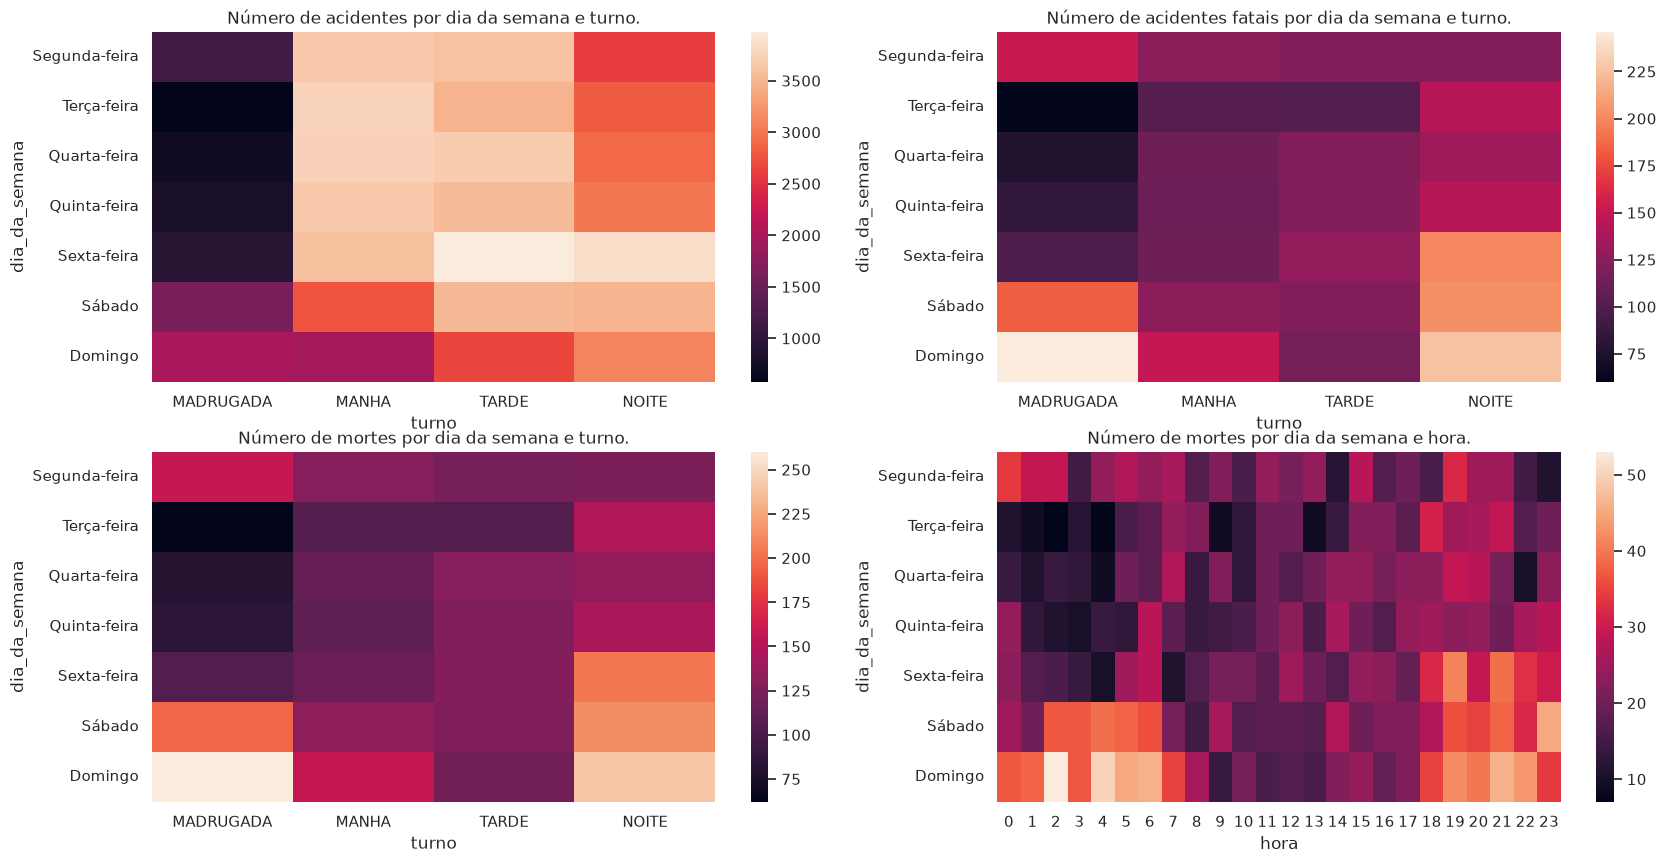

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

sns.heatmap(sinistros \
    .groupBy('dia_da_semana', 'turno').count() \
    .toPandas().pivot(index='dia_da_semana', columns='turno', values='count').reindex(index=col_order('dia_da_semana'), columns=col_order('turno')), ax=axes[0])
axes[0].set_title("Número de acidentes por dia da semana e turno.")

sns.heatmap(sinistros.filter(f.col('fatalidade') == 'SIM') \
    .groupBy('dia_da_semana', 'turno').count() \
    .toPandas().pivot(index='dia_da_semana', columns='turno', values='count').reindex(index=col_order('dia_da_semana'), columns=col_order('turno')), ax=axes[1])
axes[1].set_title("Número de acidentes fatais por dia da semana e turno.")


sns.heatmap(sinistros.filter(f.col('fatalidade') == 'SIM') \
    .groupBy('dia_da_semana', 'turno').agg(f.sum('qtd_gravidade_fatal').alias('mortes')) \
    .toPandas().pivot(index='dia_da_semana', columns='turno', values='mortes').reindex(index=col_order('dia_da_semana'), columns=col_order('turno')), ax=axes[2])
axes[2].set_title("Número de mortes por dia da semana e turno.")

sns.heatmap(sinistros.filter(f.col('fatalidade') == 'SIM') \
    .groupBy('dia_da_semana', 'hora').agg(f.sum('qtd_gravidade_fatal').alias('mortes')) \
    .toPandas().pivot(index='dia_da_semana', columns='hora', values='mortes').reindex(index=col_order('dia_da_semana')), ax=axes[3])
axes[3].set_title("Número de mortes por dia da semana e hora.")


In [ ]:
sinistros.filter(f.col('fatalidade') == 'SIM') \
    .groupBy('dia_da_semana', 'turno').count() \
    .withColumn('percentual_mortes', f.col('count') / f.sum('count').over(Window.partitionBy())) \
    .withColumn('acumulado_mortes', f.sum(f.col('count')).over(
        Window.partitionBy().orderBy(f.col('count').desc()).rangeBetween(Window.unboundedPreceding, Window.currentRow)) 
                                                               / f.sum('count').over(Window.partitionBy())) \
    .orderBy(f.col('count').desc()) \
    .toPandas()

,dia_da_semana,turno,count,percentual_mortes,acumulado_mortes
0,Domingo,MADRUGADA,246,0.065828,0.065828
1,Domingo,NOITE,226,0.060476,0.126305
2,Sábado,NOITE,203,0.054322,0.180626
3,Sexta-feira,NOITE,200,0.053519,0.234145
4,Sábado,MADRUGADA,183,0.048970,0.283115
5,Segunda-feira,MADRUGADA,152,0.040674,0.323789
6,Domingo,MANHA,150,0.040139,0.363928
7,Terça-feira,NOITE,144,0.038534,0.440995
8,Quinta-feira,NOITE,144,0.038534,0.440995
9,Quarta-feira,NOITE,133,0.035590,0.476585


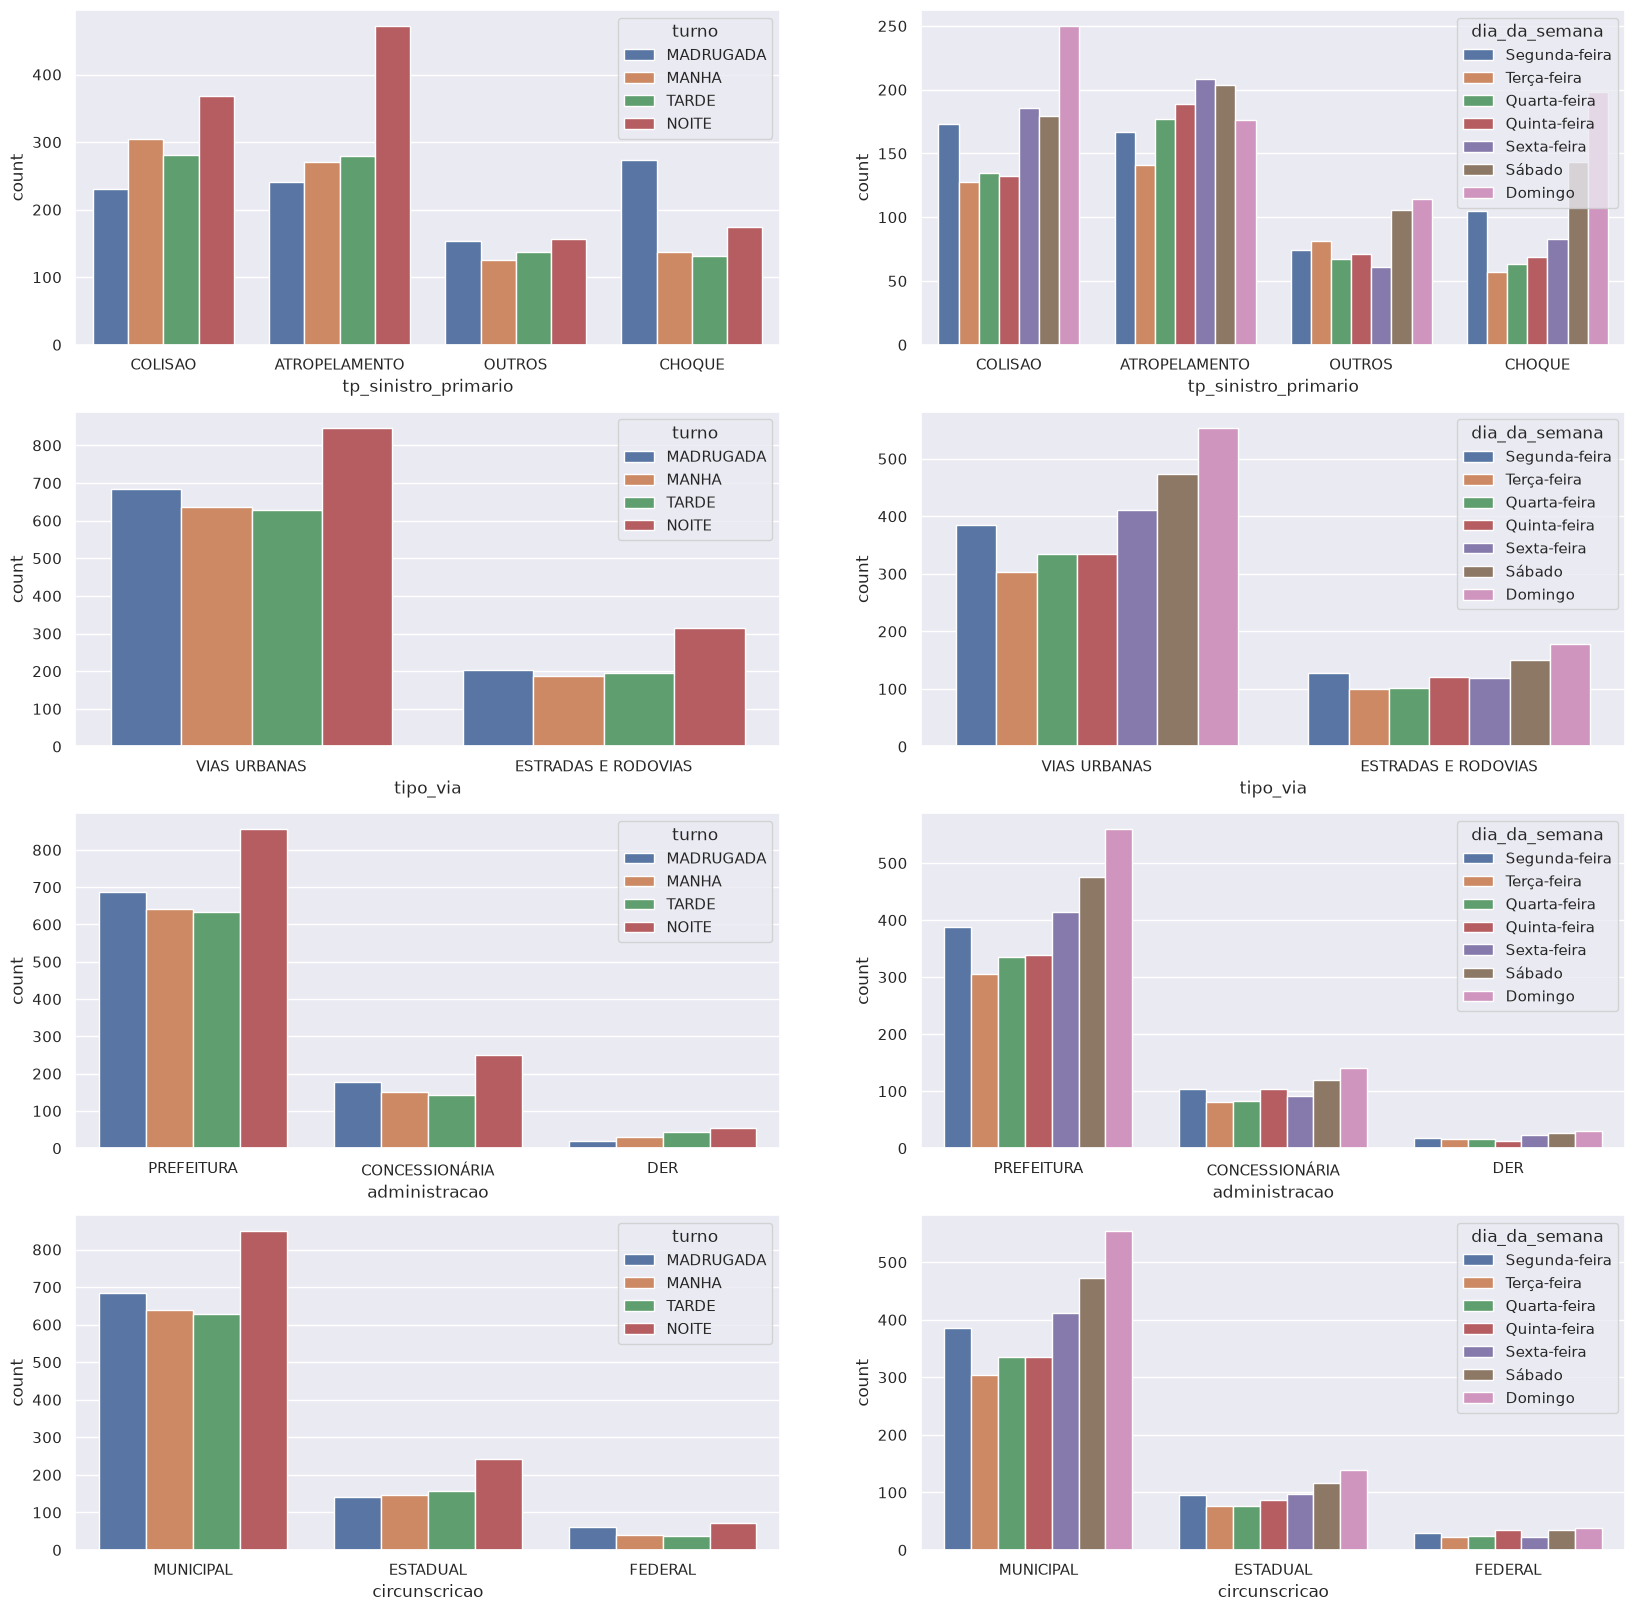

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
x_columns = ['tp_sinistro_primario', 'tipo_via', 'administracao', 'circunscricao']
hue_columns = ['turno', 'dia_da_semana']
for i, column in enumerate(x_columns):
    for j, hue_col in enumerate(hue_columns):
        filtrado = sinistros.filter(f.col('fatalidade') == 'SIM') \
            .filter(f.col(column) != 'NAO DISPONIVEL')
        sns.countplot(data=filtrado.toPandas(), x=column, hue=hue_col, ax=axes[i][j], hue_order=col_order(hue_col))

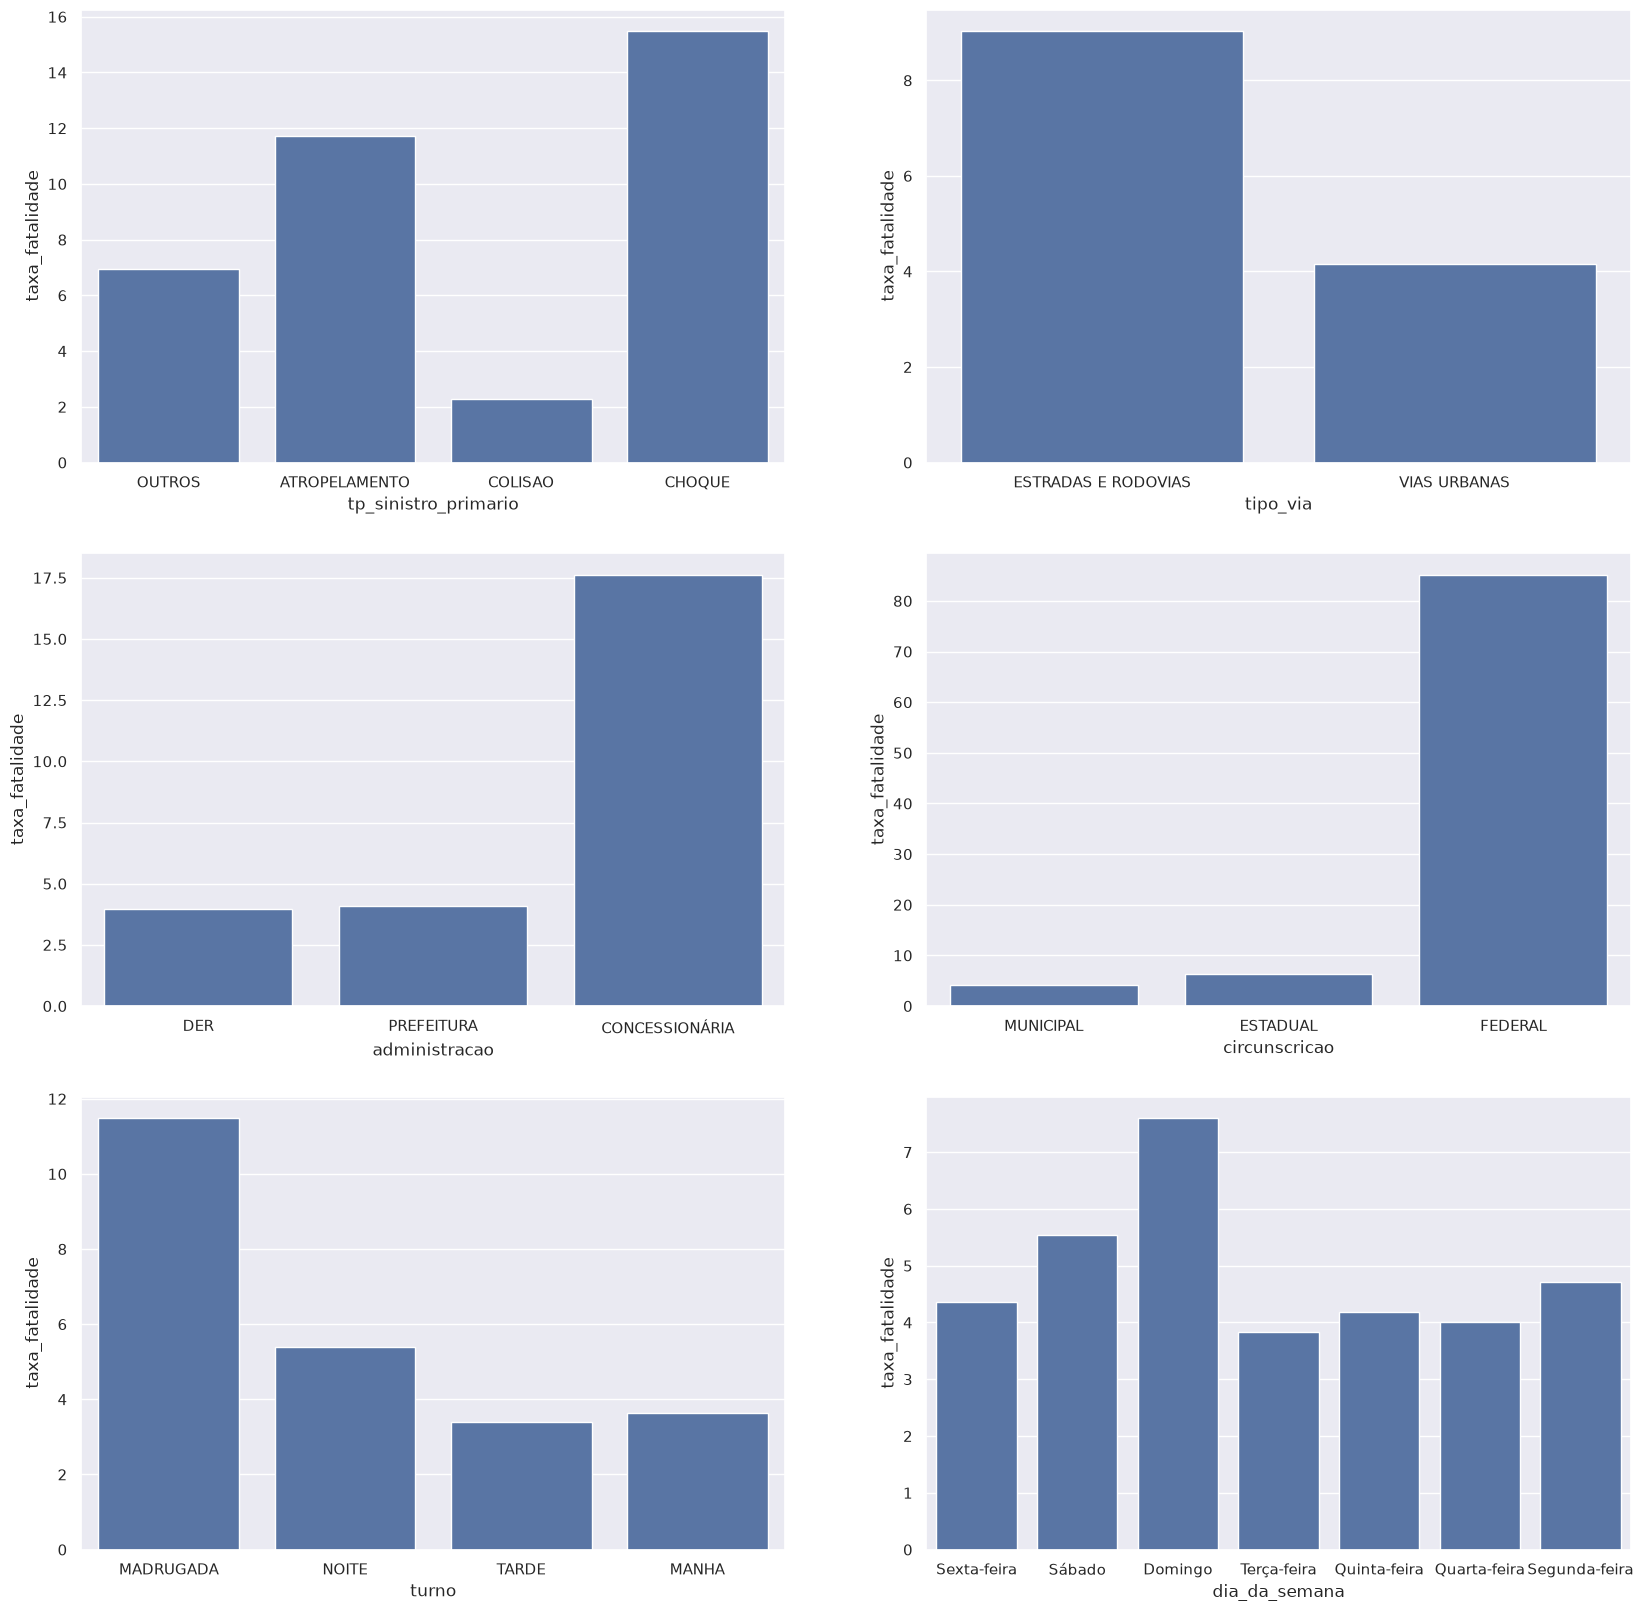

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
x_columns = ['tp_sinistro_primario', 'tipo_via', 'administracao', 'circunscricao', 'turno', 'dia_da_semana']
axes = axes.flatten()
for i, column in enumerate(x_columns):
    agrupado = sinistros \
        .groupBy(column).agg((f.sum(f.when(f.col('fatalidade') == 'SIM', 1).otherwise(0)) * 100 / f.count(f.col('fatalidade'))).alias('taxa_fatalidade')) \
        .filter(f.col(column) != 'NAO DISPONIVEL')
    sns.barplot(data=agrupado.toPandas(), x=column, y='taxa_fatalidade', ax=axes[i])

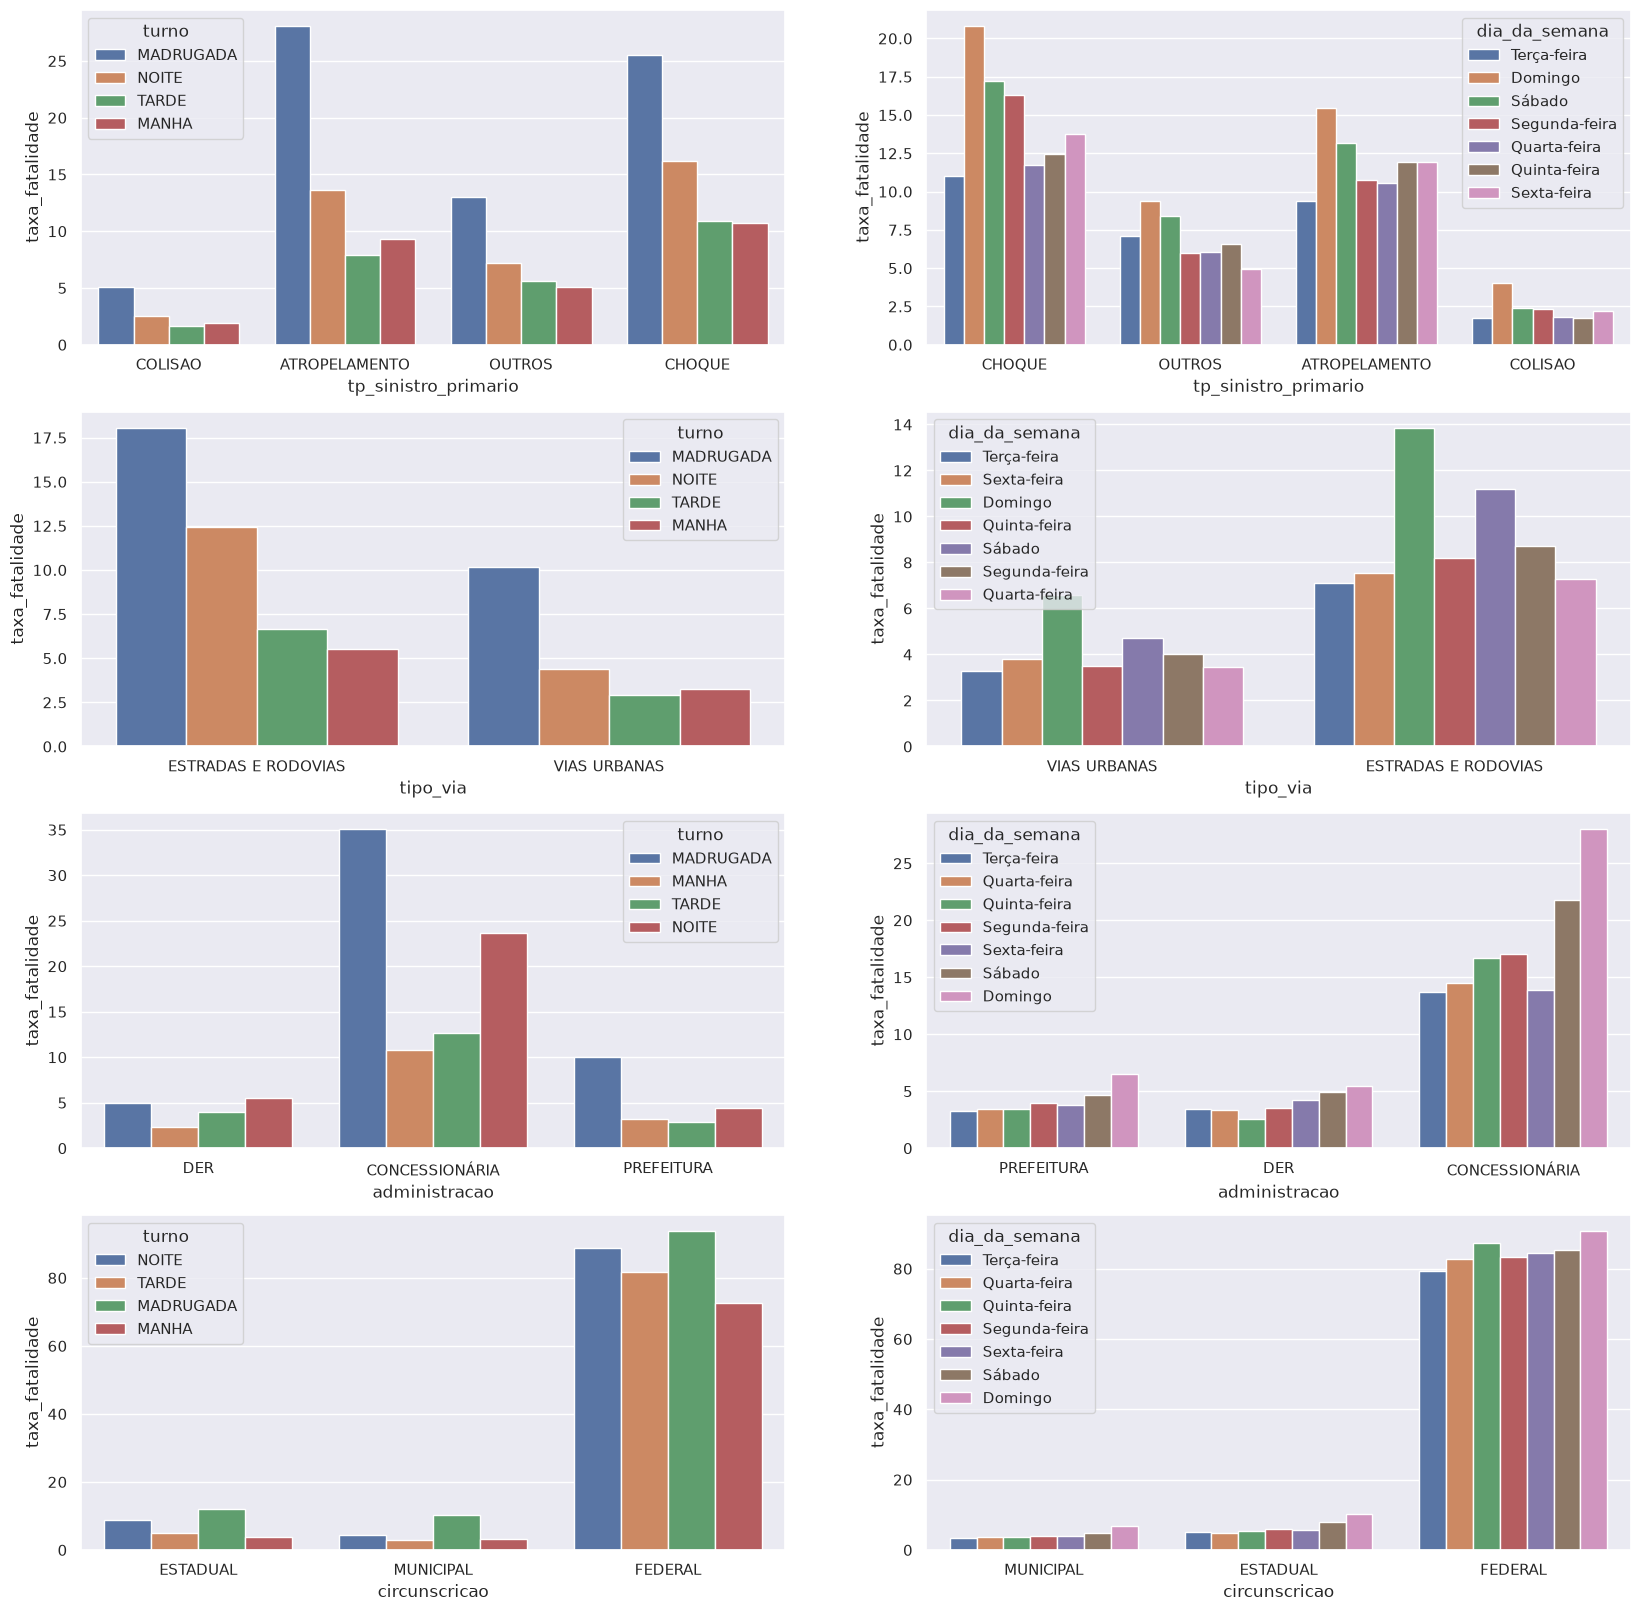

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
x_columns = ['tp_sinistro_primario', 'tipo_via', 'administracao', 'circunscricao']
hue_columns = ['turno', 'dia_da_semana']
for i, column in enumerate(x_columns):
    for j, hue_col in enumerate(hue_columns):
        agrupado = sinistros \
            .groupBy(column, hue_col).agg((f.sum(f.when(f.col('fatalidade') == 'SIM', 1).otherwise(0)) * 100 / f.count(f.col('fatalidade'))).alias('taxa_fatalidade')) \
            .filter(f.col(column) != 'NAO DISPONIVEL')
        sns.barplot(data=agrupado.toPandas(), x=column, y='taxa_fatalidade', hue=hue_col, ax=axes[i][j])